In [ ]:
MULTIPLE LINEAR REGRESSION
Assignment Task:
Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.
Dataset Description:
The dataset consists of the following variables:
Age: Age in years
KM: Accumulated Kilometers on odometer
FuelType: Fuel Type (Petrol, Diesel, CNG)
HP: Horse Power
Automatic: Automatic ( (Yes=1, No=0)
CC: Cylinder Volume in cubic centimeters
Doors: Number of doors
Weight: Weight in Kilograms
Quarterly_Tax: 
Price: Offer Price in EUROs
Tasks:
1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.
2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).
3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.
4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.
5.Apply Lasso and Ridge methods on the model.

Interview Questions:
1.What is Normalization & Standardization and how is it helpful?
2.What techniques can be used to address multicollinearity in multiple linear regression?


Ensure to properly comment your code and provide explanations for your analysis.
Include any assumptions made during the analysis and discuss their implications.


In [6]:

import pandas as pd
df = pd.read_csv("/Users/SS/Downloads/Multiple Linear Regression/ToyotaCorolla - MLR.csv")   
df


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [8]:
print("\nFirst 5 rows:")
print(df.head())



First 5 rows:
   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  


In [9]:

print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None


In [10]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.38677     0.952677        0.0     0.188510    52.64112  
min  

In [11]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


In [12]:
# Fill missing values (numeric → mean)
df.fillna(df.mean(numeric_only=True), inplace=True)


In [13]:
# Drop duplicates
df.drop_duplicates(inplace=True)

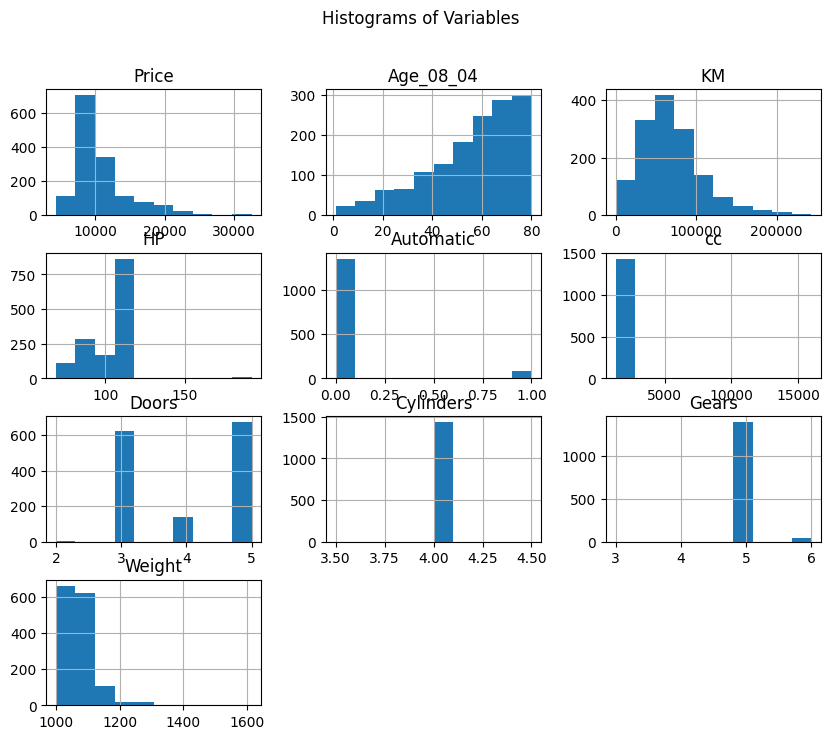

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(10, 8))
plt.suptitle("Histograms of Variables")
plt.show()


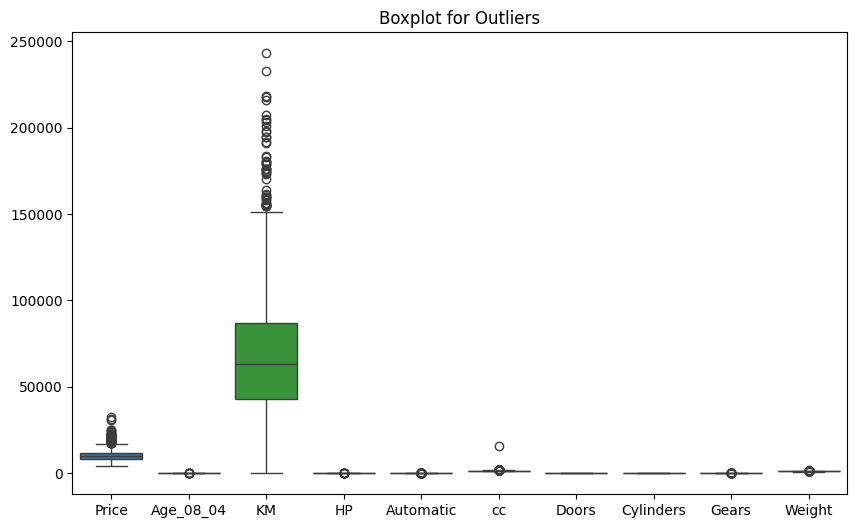

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title("Boxplot for Outliers")
plt.show()

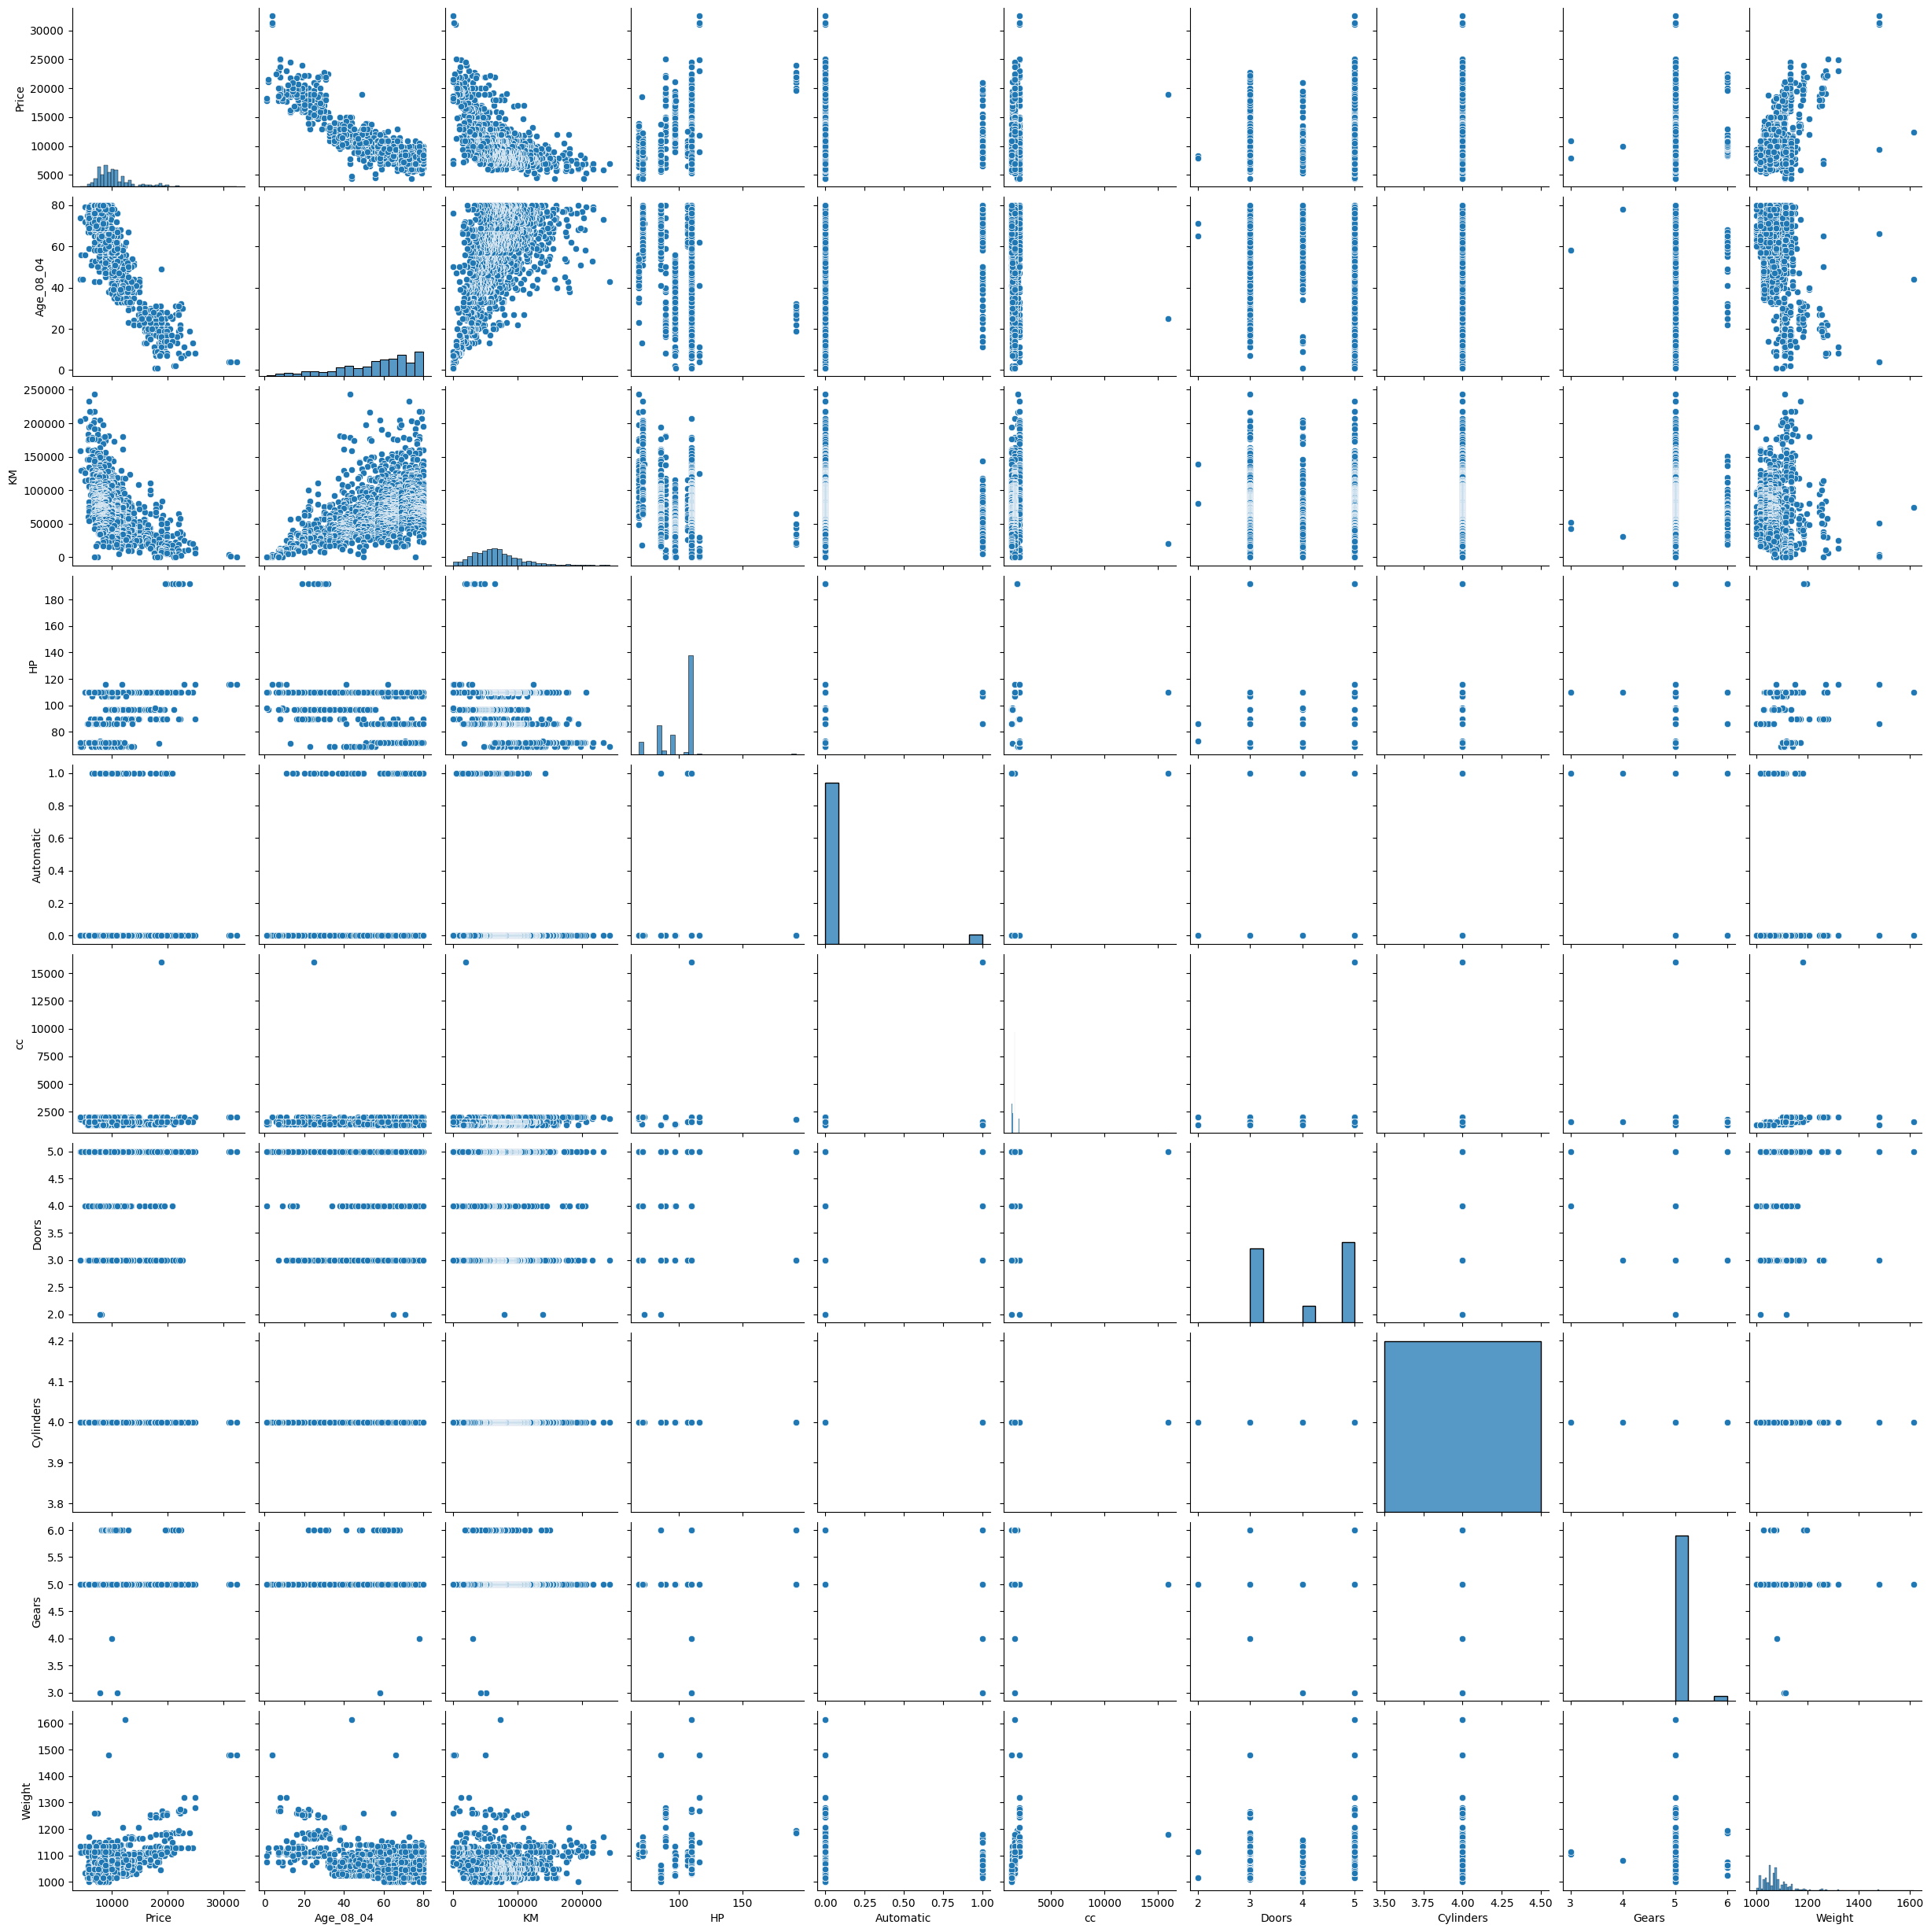

In [18]:
sns.pairplot(df)
plt.show()

In [30]:

# Feature Scaling (Standardization)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X = pd.DataFrame(X_scaled, columns=X.columns)

# -------------------------------
# Final Output
# -------------------------------
print("\nPreprocessed Features (X):")
print(X.head())

print("\nTarget Variable (Y):")
print(Y.head())


Preprocessed Features (X):
      Price  Age_08_04        KM        HP  Automatic        cc     Doors  \
0  0.770368  -1.777268 -0.575958 -0.767351  -0.242983  0.998113 -1.084443   
1  0.839669  -1.777268  0.116474 -0.767351  -0.242983  0.998113 -1.084443   
2  0.895109  -1.723380 -0.716707 -0.767351  -0.242983  0.998113 -1.084443   
3  1.172311  -1.615603 -0.548902 -0.767351  -0.242983  0.998113 -1.084443   
4  0.839669  -1.400049 -0.802384 -0.767351  -0.242983  0.998113 -1.084443   

      Gears    Weight  Fuel_Type_Diesel  Fuel_Type_Petrol  
0 -0.140475  1.774964          2.884126         -2.718789  
1 -0.140475  1.774964          2.884126         -2.718789  
2 -0.140475  1.774964          2.884126         -2.718789  
3 -0.140475  1.774964          2.884126         -2.718789  
4 -0.140475  1.870688          2.884126         -2.718789  

Target Variable (Y):
0    4
1    4
2    4
3    4
4    4
Name: Cylinders, dtype: int64


In [31]:
# Convert categorical variables → numerical (if any)
df = pd.get_dummies(df, drop_first=True)

# Define dependent (Y) and independent variables (X)
# Change 'Target' to your actual column name
X = df.drop("Doors", axis=1)
Y = df["Doors"]

# Feature Scaling (Standardization)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X = pd.DataFrame(X_scaled, columns=X.columns)

# -------------------------------
# Final Output
# -------------------------------
print("\nPreprocessed Features (X):")
print(X.head())

print("\nTarget Variable (Y):")
print(Y.head())


Preprocessed Features (X):
      Price  Age_08_04        KM        HP  Automatic        cc  Cylinders  \
0  0.770368  -1.777268 -0.575958 -0.767351  -0.242983  0.998113        0.0   
1  0.839669  -1.777268  0.116474 -0.767351  -0.242983  0.998113        0.0   
2  0.895109  -1.723380 -0.716707 -0.767351  -0.242983  0.998113        0.0   
3  1.172311  -1.615603 -0.548902 -0.767351  -0.242983  0.998113        0.0   
4  0.839669  -1.400049 -0.802384 -0.767351  -0.242983  0.998113        0.0   

      Gears    Weight  Fuel_Type_Diesel  Fuel_Type_Petrol  
0 -0.140475  1.774964          2.884126         -2.718789  
1 -0.140475  1.774964          2.884126         -2.718789  
2 -0.140475  1.774964          2.884126         -2.718789  
3 -0.140475  1.774964          2.884126         -2.718789  
4 -0.140475  1.870688          2.884126         -2.718789  

Target Variable (Y):
0    3
1    3
2    3
3    3
4    3
Name: Doors, dtype: int64


In [32]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (1148, 11)
Testing size: (287, 11)


In [33]:
from sklearn.linear_model import LinearRegression

# Model 1: All features
model1 = LinearRegression()
model1.fit(X_train, Y_train)

# Model 2: First 2 features only
X_train_m2 = X_train.iloc[:, :2]
X_test_m2 = X_test.iloc[:, :2]

model2 = LinearRegression()
model2.fit(X_train_m2, Y_train)

# Model 3: First 3 features only
X_train_m3 = X_train.iloc[:, :3]
X_test_m3 = X_test.iloc[:, :3]

model3 = LinearRegression()
model3.fit(X_train_m3, Y_train)

LinearRegression()

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, Y_test, name):
    Y_pred = model.predict(X_test)
    
    print(f"\n{name} Performance:")
    print("MAE:", mean_absolute_error(Y_test, Y_pred))
    print("MSE:", mean_squared_error(Y_test, Y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))
    print("R2 Score:", r2_score(Y_test, Y_pred))

# Evaluate all models
evaluate_model(model1, X_test, Y_test, "Model 1")
evaluate_model(model2, X_test_m2, Y_test, "Model 2")
evaluate_model(model3, X_test_m3, Y_test, "Model 3")


Model 1 Performance:
MAE: 0.7825319292940685
MSE: 0.8086103336325083
RMSE: 0.8992276317109635
R2 Score: 0.11562002641045155

Model 2 Performance:
MAE: 0.887286097335005
MSE: 0.8674531374064878
RMSE: 0.9313716430117935
R2 Score: 0.05126344440414554

Model 3 Performance:
MAE: 0.8822289005568542
MSE: 0.8595707417269063
RMSE: 0.9271303801121535
R2 Score: 0.059884448357452436


In [36]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, Y_train)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, Y_train)

print("\nRidge R2:", r2_score(Y_test, ridge.predict(X_test)))
print("Lasso R2:", r2_score(Y_test, lasso.predict(X_test)))


Ridge R2: 0.11724225559272206
Lasso R2: 0.11676089666083078
